In [1]:
# This allows us to import from all folders one level up from notebooks folder - run 1 time
import sys
from pathlib import Path

print('All paths pre-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")
print('-'*100)

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))
print('All paths post-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")


All paths pre-append
0: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python311.zip
1: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11
2: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/site-packages
----------------------------------------------------------------------------------------------------
All paths post-append
0: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python311.zip
1: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11
2: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/site-packages
5: /Users/irabandutta/Developer/2026-08-llm-from-scratch


# Imports

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.model.llm import LLM
from src.training.trainer import LLMTrainer

# Terminal STDOut
![MoE snapshot](moe_default_terminal_stdout.png)

# Load artifacts

In [3]:
best_ckpt_path = '/Users/irabandutta/Developer/2026-08-llm-from-scratch/checkpoints/2026_09_03_01_55_06/best.pt'
moe_stats_csv_path = '/Users/irabandutta/Developer/2026-08-llm-from-scratch/logs/2026_09_03_01_55_06/moe_stats.csv'
train_log_path = '/Users/irabandutta/Developer/2026-08-llm-from-scratch/logs/2026_09_03_01_55_06/train.log'

best_ckpt = torch.load(best_ckpt_path, map_location='cpu', weights_only=False)
df_moe_stats = pd.read_csv(moe_stats_csv_path)

# Plot Losses

In [4]:
best_ckpt.keys()

dict_keys(['model_state_dict', 'optimizer_state_dict', 'model_config', 'train_config', 'step', 'train_loss_hist', 'val_loss_hist', 'train_loader_state', 'rng_state'])

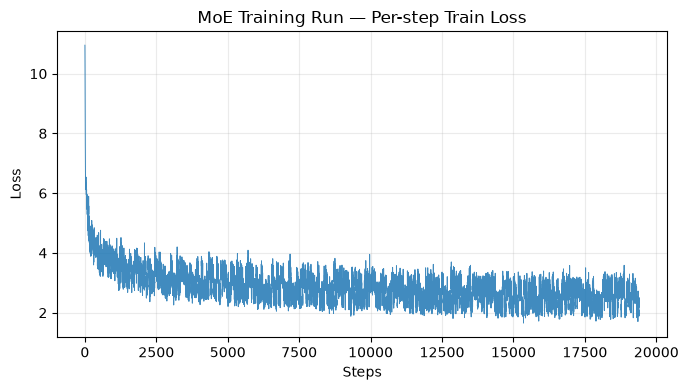

In [5]:
# Train Loss @ every step
train_loss = best_ckpt['train_loss_hist']
steps = np.arange(len(train_loss))
best_val = min(best_ckpt['val_loss_hist'])

plt.figure(figsize=(7, 4))
plt.plot(steps, train_loss, linewidth=0.7, alpha=0.85)

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('MoE Training Run — Per-step Train Loss')

plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

In [6]:
# Best Val loss found just before 20k steps
print(f"{'train_loss_length':20s}: {len(best_ckpt['train_loss_hist'])}")
print(f"{'val_loss_length':20s}: {len(best_ckpt['val_loss_hist'])}")

train_loss_length   : 19401
val_loss_length     : 98


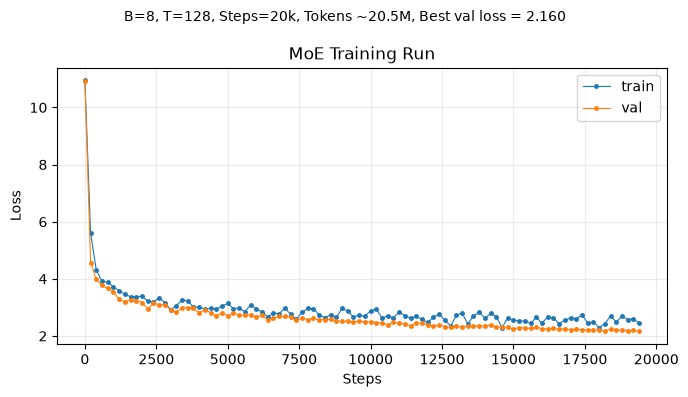

In [7]:
# Get steps
EVAL_INTERVAL = best_ckpt['train_config'].eval_interval
steps = np.arange(len(best_ckpt['val_loss_hist'])) * EVAL_INTERVAL

# Smooth train loss over steps
train_loss_smoothed = np.array(best_ckpt['train_loss_hist'][1:]).reshape(len(steps) - 1, -1).mean(axis=-1)
train_loss_smoothed = np.concatenate([[best_ckpt['train_loss_hist'][0]], train_loss_smoothed])

# Get best val loss
best_val = min(best_ckpt['val_loss_hist'])

# Plot train and val loss over steps
plt.figure(figsize=(7, 4))
plt.plot(steps, train_loss_smoothed, label='train', marker='o', markersize=2.5, linewidth=0.8)
plt.plot(steps, best_ckpt['val_loss_hist'], label='val', marker='o', markersize=2.5, linewidth=0.8)

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('MoE Training Run')
plt.suptitle('B=8, T=128, Steps=20k, Tokens ~20.5M, Best val loss = {:.3f}'.format(best_val), y=0.98, fontsize=10)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Plot LR Schedule

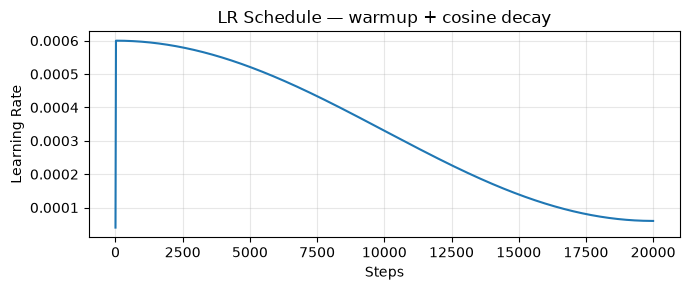

In [8]:
# This is the LR schedule defined in the trainer.py file
def get_lr(step, init_lr, final_lr, max_step, warmup_steps):
    warmup_steps_reslv = min(warmup_steps, int(0.05 * max_step))
    if step < warmup_steps_reslv:
        return init_lr * ((step + 1) / warmup_steps_reslv)
    cosine = 0.5 * (np.cos((np.pi / (max_step - warmup_steps_reslv)) * (step - warmup_steps_reslv)) + 1)
    return (init_lr - final_lr) * cosine + final_lr

tc = best_ckpt['train_config']
steps = np.arange(tc.num_steps)
lrs = [get_lr(s, tc.learning_rate, tc.min_lr, tc.num_steps, tc.warmup_steps) for s in steps]

plt.figure(figsize=(7, 3))
plt.plot(steps, lrs)
plt.xlabel('Steps'); plt.ylabel('Learning Rate')
plt.title('LR Schedule — warmup + cosine decay')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Plot Grad Norm and Training TPUT

In [9]:
steps, tputs, grad_norms = [], [], []

# Parse train.log file
with open(train_log_path, 'r') as f:
    log_data = f.readlines()
    for line in log_data:
        if not line.startswith('Step'):
            continue

        parts = line.split(', ')
        steps.append(int(parts[0].split(': ')[1]))
        tputs.append(float(parts[2].split(': ')[1].split()[0]))
        grad_norms.append(float(parts[4].split(': ')[1]))

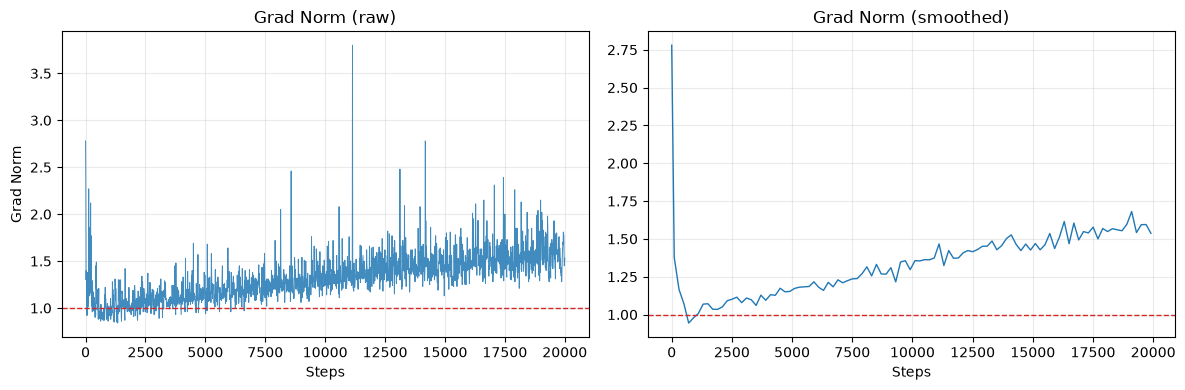

In [10]:
# Plot Grad Norm
window = 20

grad_smooth = np.array(grad_norms[1:]).reshape(-1, window).mean(axis=-1)
grad_smooth = np.concatenate([[grad_norms[0]], grad_smooth])

smooth_steps = np.array(steps[1:]).reshape(-1, window).mean(axis=-1)
smooth_steps = np.concatenate([[steps[0]], smooth_steps])

max_grad_clip = best_ckpt['train_config'].grad_clip

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(steps, grad_norms, linewidth=0.7, alpha=0.85)
plt.axhline(max_grad_clip, color='C3', linestyle='--', linewidth=1)
plt.xlabel('Steps'); plt.ylabel('Grad Norm')
plt.title('Grad Norm (raw)')
plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')

plt.subplot(1, 2, 2)
plt.plot(smooth_steps, grad_smooth, linewidth=1.0)
plt.axhline(max_grad_clip, color='C3', linestyle='--', linewidth=1)
plt.xlabel('Steps')
plt.title('Grad Norm (smoothed)')
plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

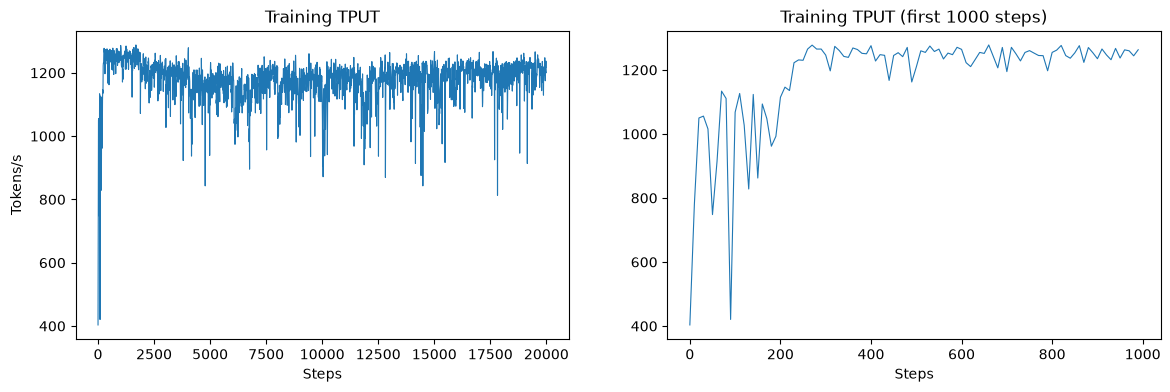

In [11]:
# Plot TPUT
LOG_INTERVAL = best_ckpt['train_config'].log_interval

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(steps, tputs, label='TPUT', linewidth=0.8)
plt.xlabel('Steps')
plt.ylabel('Tokens/s')
plt.title('Training TPUT')

plt.subplot(1, 2, 2)
init_steps = 100
plt.plot(steps[:init_steps], tputs[:init_steps], linewidth=0.8)
plt.xlabel('Steps')
# plt.ylabel('Tokens/s')
plt.title(f'Training TPUT (first {LOG_INTERVAL * init_steps} steps)')

plt.show()

# Plot MoE Routing Stats

In [12]:
from src.training.moe_routing_metrics import (
    load_moe_stats, _token_distr_by_step_layer, cv_max_over_steps, _drop_pct_by_step, fair_share
)

mc = best_ckpt['model_config']
tc = best_ckpt['train_config']

rows = load_moe_stats(moe_stats_csv_path)
stats = _token_distr_by_step_layer(rows, mc.n_experts)

moe_steps, cv, max_load = cv_max_over_steps(stats)

drop_by_step = _drop_pct_by_step(rows, mc.n_layer, tc.batch_size, mc.ctx_len, mc.topk)
drop_steps = np.array(sorted(drop_by_step.keys()))
drop_pct = np.array([drop_by_step[s] for s in drop_steps])

target = fair_share(mc.n_experts)  # 0.25 for 4 experts

## Token Distribution CV and Max_Load Ratio (Aggregated across Layers)

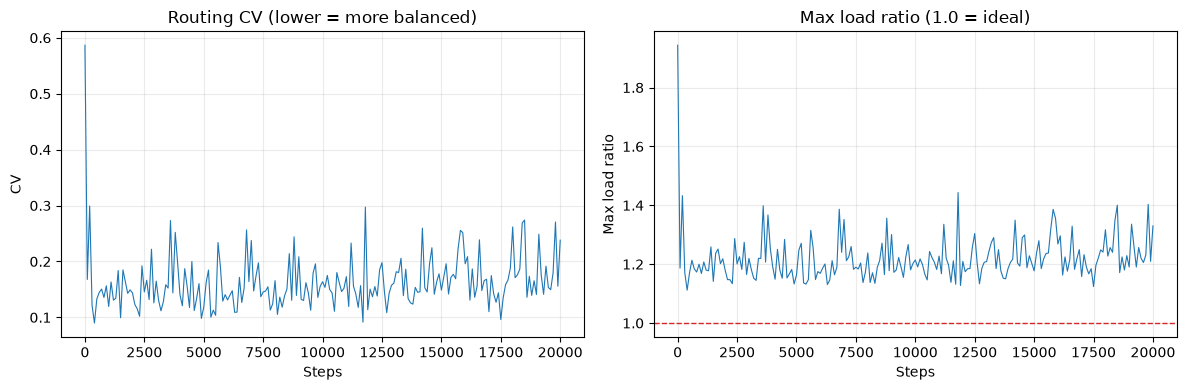

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(moe_steps, cv, linewidth=0.8)
plt.xlabel('Steps'); plt.ylabel('CV')
plt.title('Routing CV (lower = more balanced)')
plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')

plt.subplot(1, 2, 2)
plt.plot(moe_steps, max_load, linewidth=0.8)
plt.axhline(1.0, color='C3', linestyle='--', linewidth=1)
plt.xlabel('Steps'); plt.ylabel('Max load ratio')
plt.title('Max load ratio (1.0 = ideal)')
plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

# Token Drop Ratio

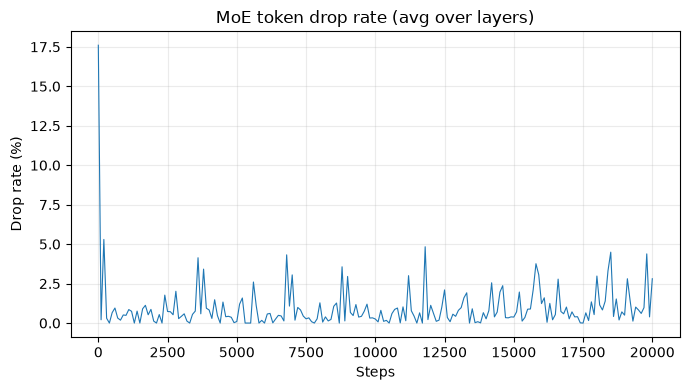

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(drop_steps, drop_pct, linewidth=0.8)
plt.xlabel('Steps'); plt.ylabel('Drop rate (%)')
plt.title('MoE token drop rate (avg over layers)')
plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

## Layer Wise Token Distribution

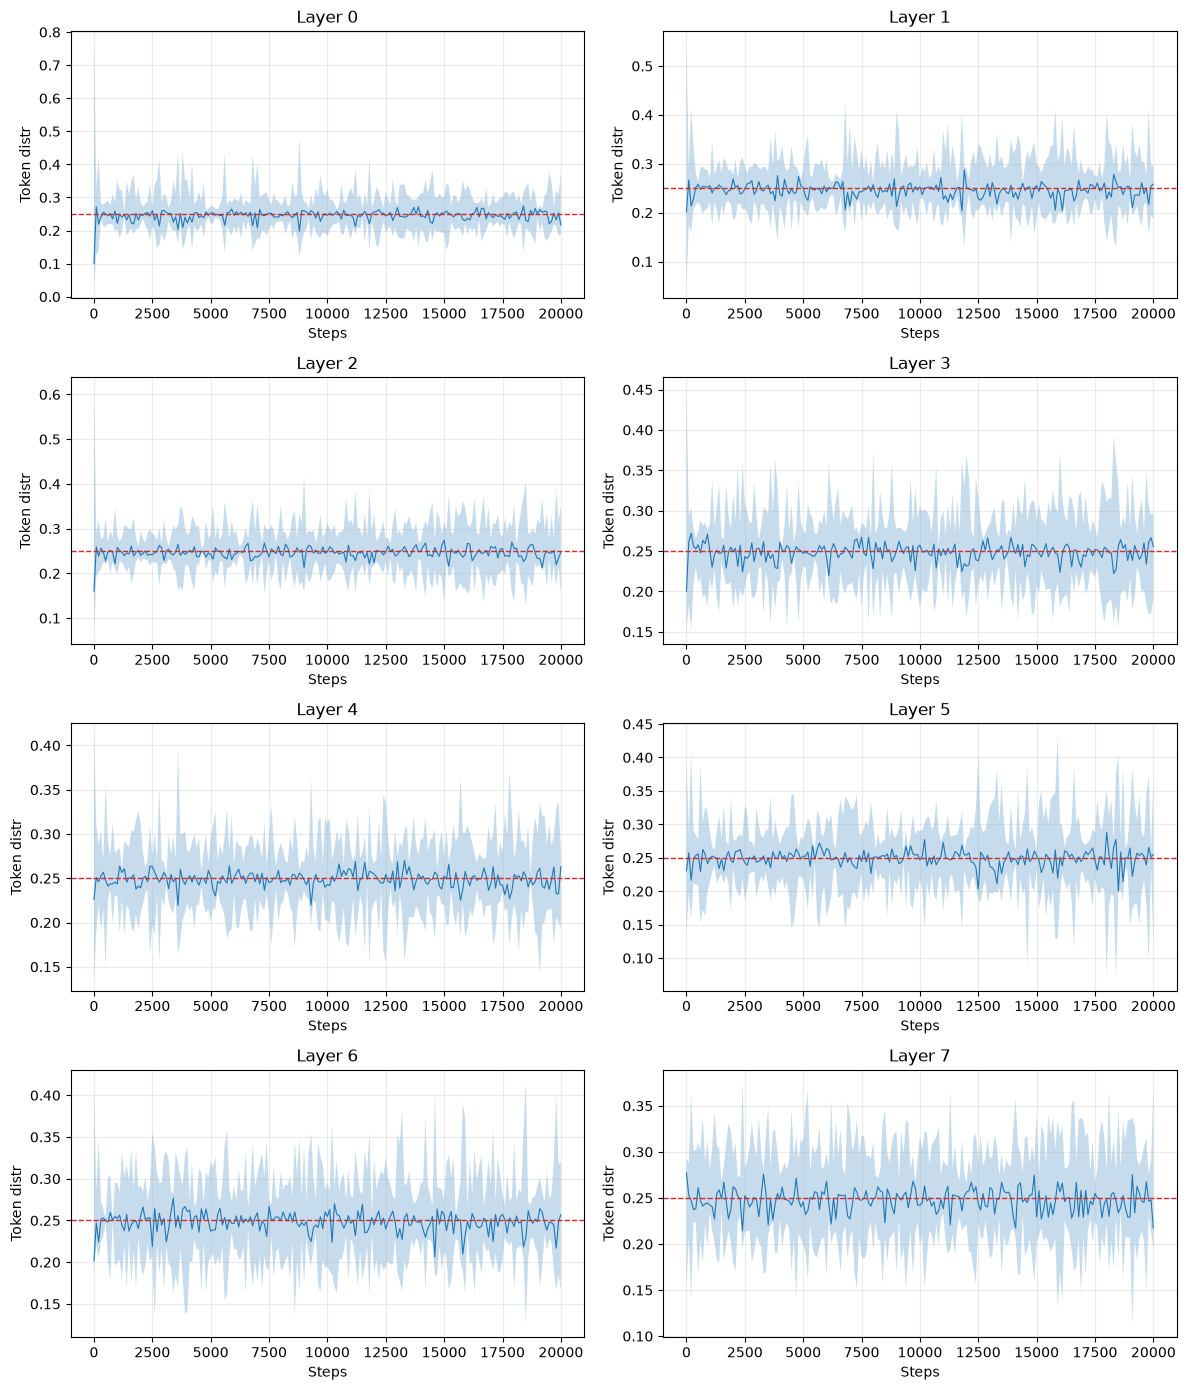

In [15]:
layers = sorted(df_moe_stats.layer.unique())
steps_logged = sorted(stats.keys())

plt.figure(figsize=(12, 14))

for i, layer in enumerate(layers):
    plt.subplot(4, 2, i + 1)
    mins, meds, maxs = [], [], []
    for s in steps_logged:
        d = stats[s][layer]
        mins.append(d.min())
        meds.append(np.median(d))
        maxs.append(d.max())
    plt.fill_between(steps_logged, mins, maxs, alpha=0.25)
    plt.plot(steps_logged, meds, linewidth=0.8)
    plt.axhline(target, color='C3', linestyle='--', linewidth=1)
    plt.title(f'Layer {layer}')
    plt.xlabel('Steps'); plt.ylabel('Token distr')
    plt.grid(alpha=0.25)
    plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

## Worst MoE Layer Analysis

layer
5    0.1461
2    0.1305
1    0.1242
0    0.1204
7    0.1158
3    0.1133
6    0.1108
4    0.1044
Name: 20000, dtype: float64
Worst layer: L5


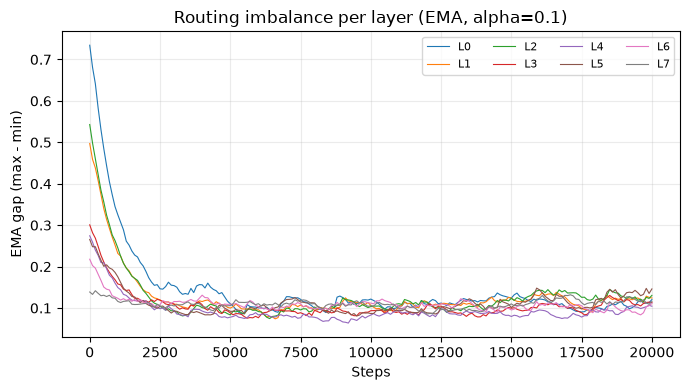

In [16]:
gaps = (
    df_moe_stats.groupby(['step', 'layer'])['token_distr']
    .agg(lambda x: x.max() - x.min())
    .reset_index(name='gap')
)
gap_wide = gaps.pivot(index='step', columns='layer', values='gap').sort_index()

alpha = 0.1
ema_gap = gap_wide.ewm(alpha=alpha, adjust=False).mean()

layer_scores = ema_gap.iloc[-1].sort_values(ascending=False)
worst_layer = int(layer_scores.idxmax())
print(layer_scores.round(4))
print(f'Worst layer: L{worst_layer}')

plt.figure(figsize=(7, 4))
for layer in ema_gap.columns:
    plt.plot(ema_gap.index, ema_gap[layer], linewidth=0.8, label=f'L{layer}')
plt.xlabel('Steps'); plt.ylabel('EMA gap (max - min)')
plt.title(f'Routing imbalance per layer (EMA, alpha={alpha})')
plt.legend(ncol=4, fontsize=8)
plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

## Worst Layer: Token Distribution across experts

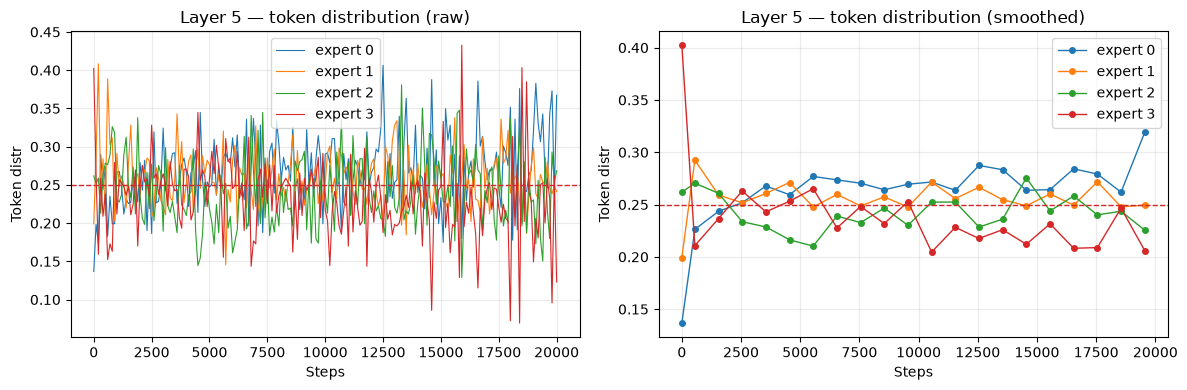

In [17]:
df_layer = df_moe_stats[df_moe_stats.layer == worst_layer].sort_values(['expert', 'step'])
window = 10

# all experts share the same logged steps
layer_steps = df_layer[df_layer.expert == 0].step.to_numpy()

plt.figure(figsize=(12, 4))

# left: raw
plt.subplot(1, 2, 1)
for e in sorted(df_layer.expert.unique()):
    sub = df_layer[df_layer.expert == e]
    plt.plot(sub.step, sub.token_distr, linewidth=0.8, label=f'expert {e}')
plt.axhline(target, color='C3', linestyle='--', linewidth=1)
plt.xlabel('Steps'); plt.ylabel('Token distr')
plt.title(f'Layer {worst_layer} — token distribution (raw)')
plt.legend(); plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')

# right: smoothed (same reshape logic as grad norm)
smooth_steps = np.array(layer_steps[1:]).reshape(-1, window).mean(axis=-1)
smooth_steps = np.concatenate([[layer_steps[0]], smooth_steps])

plt.subplot(1, 2, 2)
for e in sorted(df_layer.expert.unique()):
    sub = df_layer[df_layer.expert == e]
    d = sub.token_distr.to_numpy()
    d_smooth = np.array(d[1:]).reshape(-1, window).mean(axis=-1)
    d_smooth = np.concatenate([[d[0]], d_smooth])
    plt.plot(smooth_steps, d_smooth, linewidth=1.0, label=f'expert {e}', marker='o', markersize=4)

plt.axhline(target, color='C3', linestyle='--', linewidth=1)
plt.xlabel('Steps'); plt.ylabel('Token distr')
plt.title(f'Layer {worst_layer} — token distribution (smoothed)')
plt.legend(); plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

## Worst Layer: Raw Expert Bias (Loss Free Load Balance)

## Why raw expert bias drifts upward

### Single-expert view
- Each MoE layer keeps a per-expert **bias** for aux-loss-free load balancing
- After every training step, for each expert:
  - **Underloaded** (tokens < fair share) → bias **+0.05**
  - **Overloaded** (tokens > fair share) → bias **−0.05**
  - **Exactly at fair share** → no change
- Bias is a **running sum**, not recentered to 0:
  - `net bias change = 0.05 × (# underload steps − # overload steps)`
- For one expert over 20k steps:
  - Equal underload and overload → net change ≈ **0**
  - Bias grows → that expert was **underloaded on more steps than overloaded**
- In this run, each expert’s bias went from ~0 → ~**+29**
  - That implies ~**580 net underload steps** (`29 / 0.05`)
  - Only ~**3% more underload than overload** over the full run — a small imbalance, integrated with no reset
- Note: `moe_stats` is logged every 100 steps; late snapshots can look overloaded even when total bias is high, because early steps (esp. first ~100) already contributed a large positive integral

### Average across experts
- Same rule applies layer-wide
- On an imbalanced step (common), often **1 hot / 3 cold** experts → signs like `[+1, +1, +1, −1]`
- That step adds a **net positive** to the sum of biases across experts
- Over 20k steps, mild imbalance means **each** expert accumulates slightly more `+1` than `−1`
- That is why all raw bias curves rise together toward ~29, with only a small spread between experts (~0.6)

### What actually matters for routing
- Routing uses `router_logits + expert_bias`, then top-k
- A shared absolute level (e.g. all experts ~+29) does **not** change rankings
- Only **differences between experts** steer who gets tokens

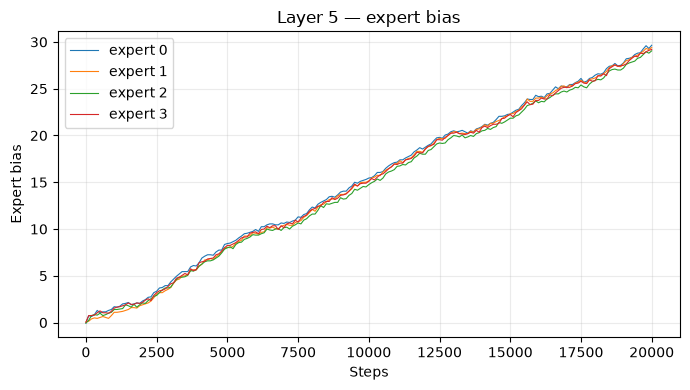

In [21]:
plt.figure(figsize=(7, 4))
for e in sorted(df_layer.expert.unique()):
    sub = df_layer[df_layer.expert == e]
    plt.plot(sub.step, sub.expert_bias, linewidth=0.8, label=f'expert {e}')

plt.xlabel('Steps'); plt.ylabel('Expert bias')
plt.title(f'Layer {worst_layer} — expert bias')
plt.legend()
plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

## Worst Layer: Relative Expert Bias (Loss Free Load Balance)

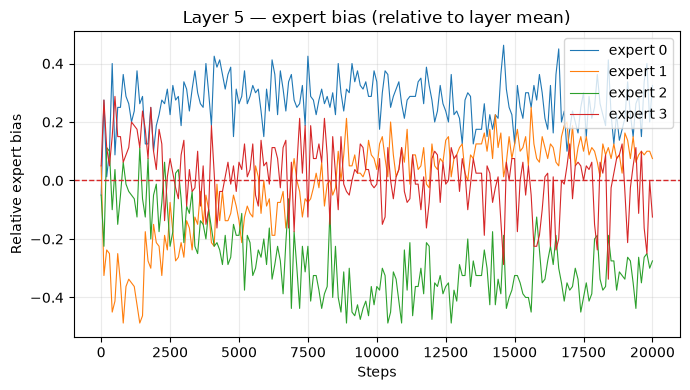

In [19]:
df_layer = df_moe_stats[df_moe_stats.layer == worst_layer].sort_values(['expert', 'step'])

# relative to layer mean at each step (this is what affects routing)
rel_bias = df_layer.groupby('step')['expert_bias'].transform(lambda x: x - x.mean())

plt.figure(figsize=(7, 4))
for e in sorted(df_layer.expert.unique()):
    sub = df_layer[df_layer.expert == e]
    plt.plot(sub.step, rel_bias[sub.index], linewidth=0.8, label=f'expert {e}')

plt.axhline(0, color='C3', linestyle='--', linewidth=1)
plt.xlabel('Steps'); plt.ylabel('Relative expert bias')
plt.title(f'Layer {worst_layer} — expert bias (relative to layer mean)')
plt.legend()
plt.grid(alpha=0.25)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()